# Seaborn

Seaborn is built on top of Matplotlib but is designed specifically for statistical data visualization. It handles DataFrames beautifully and makes complex plots—like heatmaps or regression lines—with just one line of code.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Apply the default Seaborn aesthetic
sns.set_theme(style="whitegrid")

In [6]:
df = sns.load_dataset("tips") # Seaborn has built-in toy datasets
df.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### A. Relationship Plots (scatterplot / lineplot)

Used to see how variables relate to each other. Use the hue parameter to color data by a category.

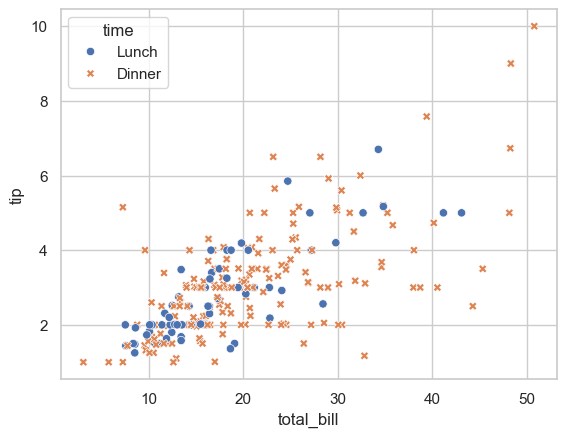

In [4]:
# Scatter plot with categories
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time", style="time")
plt.show()

### B. Distributions (histplot / kdeplot)

Perfect for understanding the "shape" of your data.

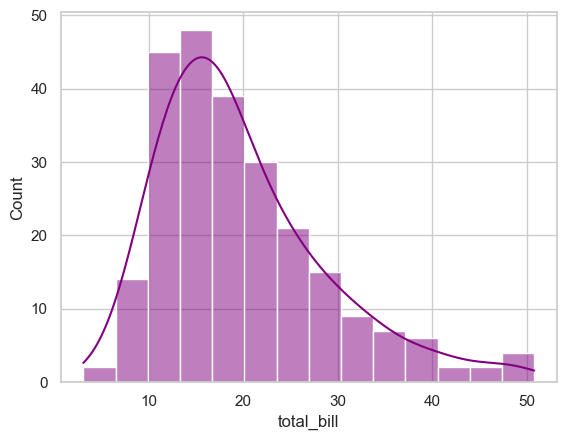

In [5]:
# Histogram + Kernel Density Estimate (the smooth line)
sns.histplot(data=df, x="total_bill", kde=True, color="purple")
plt.show()

### C. Categorical Plots (boxplot / violinplot)

Great for spotting outliers and seeing the spread of data across groups.

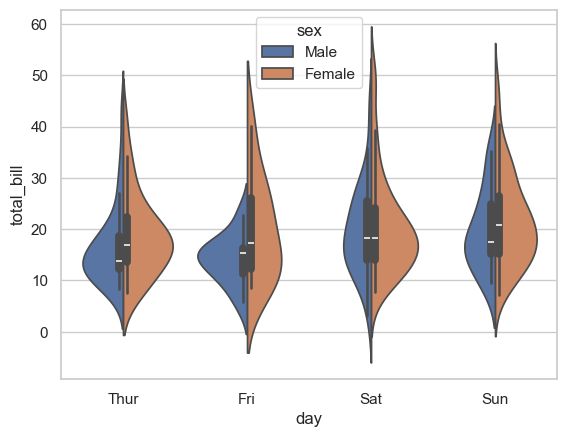

In [7]:
# Violin plots show the density of the data
sns.violinplot(data=df, x="day", y="total_bill", hue="sex", split=True)
plt.show()

### D. The Matrix Plot (heatmap)

Used frequently for Correlation Matrices to see which features are related.

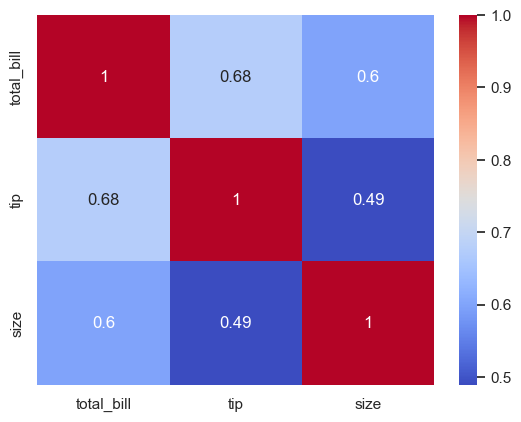

In [8]:
# Numeric correlation
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### 4. The "Magic" Functions

Seaborn has two "figure-level" functions that create multiple plots at once:

- sns.pairplot(df): Creates a grid showing every relationship in your dataset.
  
Diagonal: Shows the distribution (histogram) of each variable.

Off-diagonal: Shows scatter plots of how two variables correlate.

- sns.jointplot(): Shows the relationship between two variables plus their individual distributions on the margins.

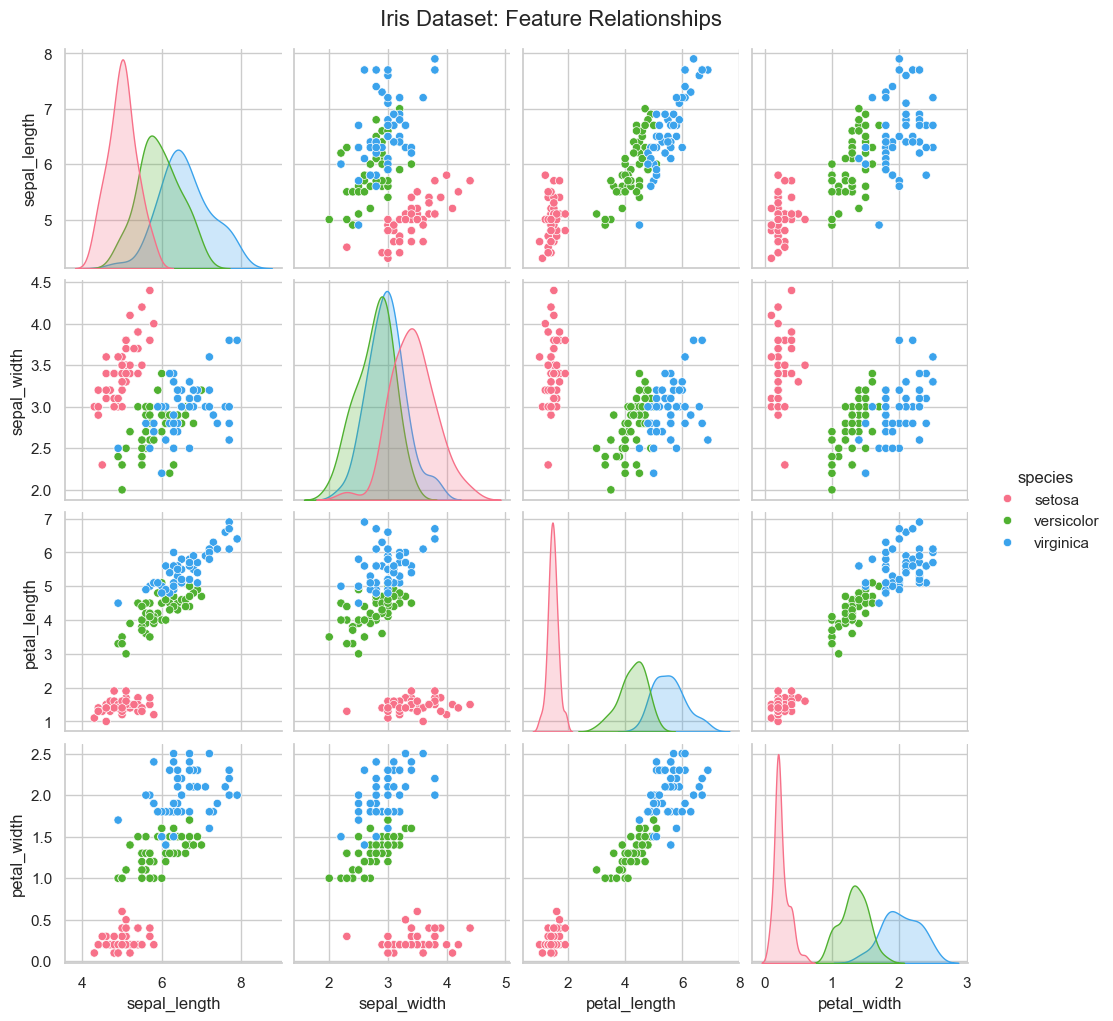

In [29]:
# Load the famous Iris dataset (flower measurements)
iris = sns.load_dataset("iris")

# Create the grid and color points by the flower species
g = sns.pairplot(iris, hue="species", palette="husl")

# Add the title to the Figure
g.fig.suptitle("Iris Dataset: Feature Relationships", y=1.02, fontsize=16)

plt.savefig("pairplot.png") # save fig

# plt.show()

### Customizing the Grid

The distinct color groups indicate that the variable is well-suited for classification.

The diagonal regression lines mean the two variables are highly correlated.

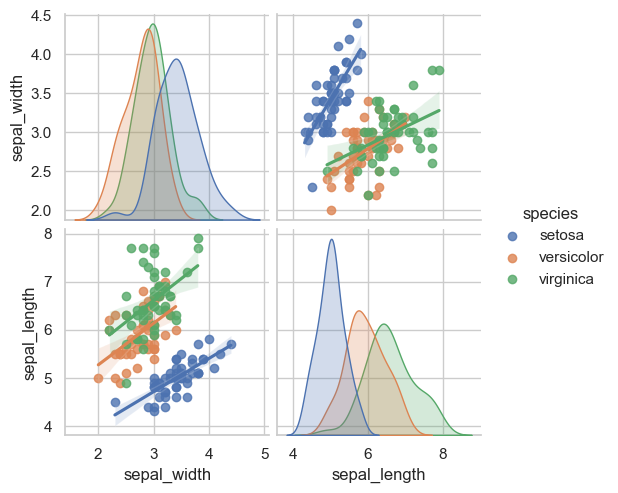

In [22]:
sns.pairplot(
    iris, 
    hue="species", 
    vars=["sepal_width", "sepal_length"], # Only plot these two
    kind="reg",                           # Add regression lines to scatter plots
    diag_kind="kde"                       # Use smooth density curves on the diagonal
)
plt.show()